# Question 26 — Olympic Games ML Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import f1_score, mean_squared_error, r2_score, classification_report, confusion_matrix

print("Libraries imported")

Libraries imported


In [2]:
df =pd.read_csv("olympic_raw_dataset.csv")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()
df.info()


Shape: (5050, 17)
Columns: ['Country', 'Sport', 'Year', 'Athletes', 'Gold', 'Silver', 'Bronze', 'Total_Medals', 'Events_Participated', 'GDP_Index', 'Population_Millions', 'Prev_Medals', 'Host', 'Medal_per_Athlete', 'Gold_Ratio', 'Participation_Rate', 'Medals_per_Million']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              5050 non-null   object 
 1   Sport                5050 non-null   object 
 2   Year                 5050 non-null   float64
 3   Athletes             4650 non-null   float64
 4   Gold                 4648 non-null   float64
 5   Silver               4645 non-null   float64
 6   Bronze               4647 non-null   float64
 7   Total_Medals         4647 non-null   float64
 8   Events_Participated  4646 non-null   float64
 9   GDP_Index            4650 non-null   float64
 10  Population_Mill

In [3]:
# CELL 3 - CHECK MISSING VALUES BEFORE CLEANING
print("Missing values BEFORE cleaning:")
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Missing values BEFORE cleaning:
Country                  0
Sport                    0
Year                     0
Athletes               400
Gold                   402
Silver                 405
Bronze                 403
Total_Medals           403
Events_Participated    404
GDP_Index              400
Population_Millions    405
Prev_Medals            407
Host                     0
Medal_per_Athlete      775
Gold_Ratio             762
Participation_Rate     774
Medals_per_Million     778
dtype: int64
Duplicates: 50


In [4]:
# CELL 4 - DATA CLEANING
# Fix Year column
df["Year"] = pd.to_numeric(df["Year"].astype(str).str.replace(".0", "", regex=False), errors="coerce")

# Fix country name inconsistencies
df["Country"] = df["Country"].str.strip().str.title()
df["Country"] = df["Country"].replace({"Usa":"USA", "U.K.":"UK", "China":"China"})

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Fix negative values
for col in ["Gold", "Silver", "Bronze"]:
    df[col] = df[col].abs()

# Fix outliers in Athletes using IQR
Q1, Q3 = df["Athletes"].quantile(0.25), df["Athletes"].quantile(0.75)
upper  = Q3 + 1.5 * (Q3 - Q1)
df["Athletes"] = df["Athletes"].apply(lambda x: df["Athletes"].median() if pd.notna(x) and x > upper else x)

# Fill missing values with median
for col in ["Athletes","Gold","Silver","Bronze","Total_Medals",
            "Events_Participated","GDP_Index","Population_Millions","Prev_Medals"]:
    df[col].fillna(df[col].median())

# Recalculate columns
df["Total_Medals"]       = df["Gold"] + df["Silver"] + df["Bronze"]
df["Medal_per_Athlete"]  = (df["Total_Medals"] / df["Athletes"]).round(4)
df["Gold_Ratio"]         = (df["Gold"] / df["Total_Medals"].replace(0, 1)).round(4)
df["Participation_Rate"] = (df["Athletes"] / df["Events_Participated"]).round(4)
df["Medals_per_Million"] = (df["Total_Medals"] / df["Population_Millions"]).round(4)

print("Cleaned shape:", df.shape)
print("Missing values AFTER cleaning:")
print(df.isnull().sum())

Cleaned shape: (5000, 17)
Missing values AFTER cleaning:
Country                   0
Sport                     0
Year                      0
Athletes                395
Gold                    399
Silver                  400
Bronze                  400
Total_Medals           1099
Events_Participated     400
GDP_Index               397
Population_Millions     400
Prev_Medals             400
Host                      0
Medal_per_Athlete      1409
Gold_Ratio             1099
Participation_Rate      766
Medals_per_Million     1414
dtype: int64


In [5]:
# CELL 5 - STATISTICAL SUMMARY
df[["Athletes","Gold","Silver","Bronze","Total_Medals","GDP_Index"]].describe().round(2)

,Athletes,Gold,Silver,Bronze,Total_Medals,GDP_Index
count,4605.00,4601.00,4600.00,4600.00,3901.00,4603.00
mean,30.29,1.81,1.56,1.55,4.91,0.62
std,17.03,1.56,1.49,1.45,3.78,0.97
min,1.00,0.00,0.00,0.00,0.00,0.10
25%,16.00,0.00,0.00,0.00,2.00,0.32
50%,31.00,2.00,1.00,1.00,4.00,0.55
75%,45.00,3.00,3.00,3.00,8.00,0.78
max,63.00,9.93,9.48,5.00,17.23,18.45


In [6]:
import numpy as np
df['GDP_x_Athletes'] = df['GDP_Index'] * df['Athletes']
df['Host_x_Athletes'] = df['Host'] * df['Athletes']

# Bending the 'straight line' to fit the curve of success
df['Athletes_Squared'] = df['Athletes'] ** 2
# Making the 'Giant' countries easier for a linear model to handle
# Use .apply(np.log1p) to handle zeros safely
df['Log_Population'] = np.log1p(df['Population_Millions'])

print("New features created: GDP_x_Athletes, Host_x_Athletes, Athletes_Squared, Log_Population")

New features created: GDP_x_Athletes, Host_x_Athletes, Athletes_Squared, Log_Population


In [7]:
# CELL 6 - NORMALIZATION & ENCODING
le = LabelEncoder()
df["Country_Code"] = le.fit_transform(df["Country"])
df["Sport_Code"]   = le.fit_transform(df["Sport"])

features = ["Athletes","Events_Participated","GDP_Index",
            "Population_Millions","Prev_Medals","Host",
            "Medal_per_Athlete","Gold_Ratio",
            "Participation_Rate","Medals_per_Million",
            "Country_Code","Year","Sport_Code","GDP_x_Athletes",
            "Host_x_Athletes","Athletes_Squared","Log_Population"]

X     = df[features].fillna(df[features].median())
y_reg = df["Total_Medals"]

# StandardScaler
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

print("Features:", features)
print("X_scaled shape:", X_scaled.shape)
X_scaled.head()

Features: ['Athletes', 'Events_Participated', 'GDP_Index', 'Population_Millions', 'Prev_Medals', 'Host', 'Medal_per_Athlete', 'Gold_Ratio', 'Participation_Rate', 'Medals_per_Million', 'Country_Code', 'Year', 'Sport_Code', 'GDP_x_Athletes', 'Host_x_Athletes', 'Athletes_Squared', 'Log_Population']
X_scaled shape: (5000, 17)


,Athletes,Events_Participated,GDP_Index,Population_Millions,Prev_Medals,Host,Medal_per_Athlete,Gold_Ratio,Participation_Rate,Medals_per_Million,Country_Code,Year,Sport_Code,GDP_x_Athletes,Host_x_Athletes,Athletes_Squared,Log_Population
0,0.039810,1.036568,-0.067951,1.131790,1.472819,-0.090927,-0.203460,0.427822,-0.247762,-0.103461,0.486887,-0.003151,-0.159622,-0.156476,-0.079128,-0.222598,0.812000
1,-0.021380,-1.769798,-0.165510,-0.750150,0.127730,-0.090927,-0.126560,-0.195393,5.218310,-0.027157,-0.211960,0.381108,0.190120,-0.144816,-0.079128,-0.282372,-0.269530
2,-1.489947,0.298051,-0.269502,-0.959056,0.127730,-0.090927,0.715903,-0.195393,-0.442300,0.008507,0.268497,-0.771670,0.539862,-0.524973,-0.079128,-1.129011,-0.503486
3,-1.489947,-1.695946,-0.067951,-0.131775,-0.141288,-0.090927,-0.203460,-0.008468,0.088382,-0.115072,-0.692418,-0.387410,-1.558592,-0.156476,-0.079128,-1.129011,0.218404
4,0.468142,0.519606,-0.067951,-0.884167,0.396748,-0.090927,-0.170877,-0.195393,-0.255989,-0.005592,0.224819,1.149627,1.239347,-0.156476,-0.079128,0.250697,-0.413516


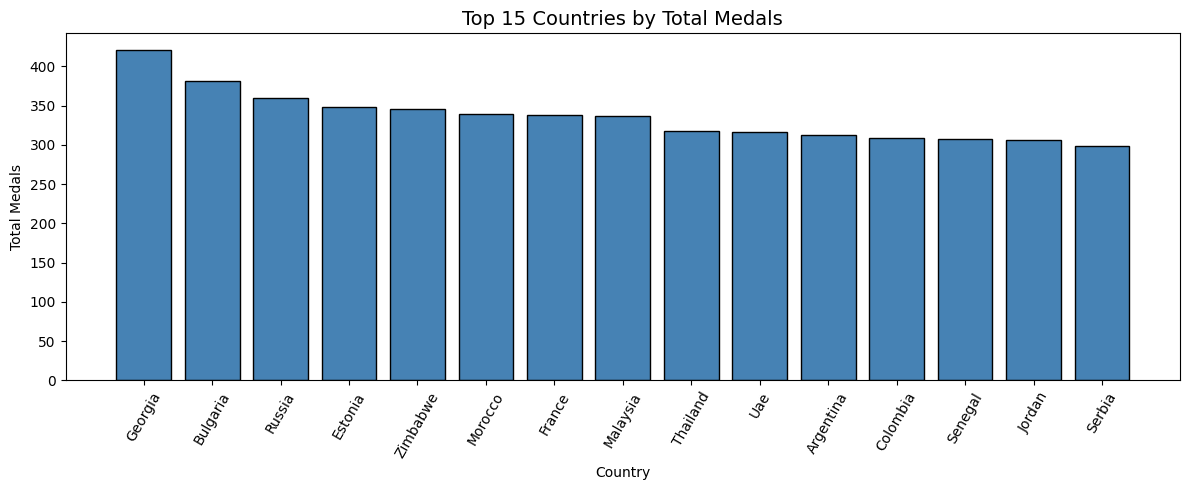

In [8]:
# CELL 7 - EDA : BAR CHART (Top 15 Countries)
top15 = df.groupby("Country")["Total_Medals"].sum().nlargest(15)
plt.figure(figsize=(12, 5))
plt.bar(top15.index, top15.values, color="steelblue", edgecolor="black")
plt.title("Top 15 Countries by Total Medals", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Total Medals")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

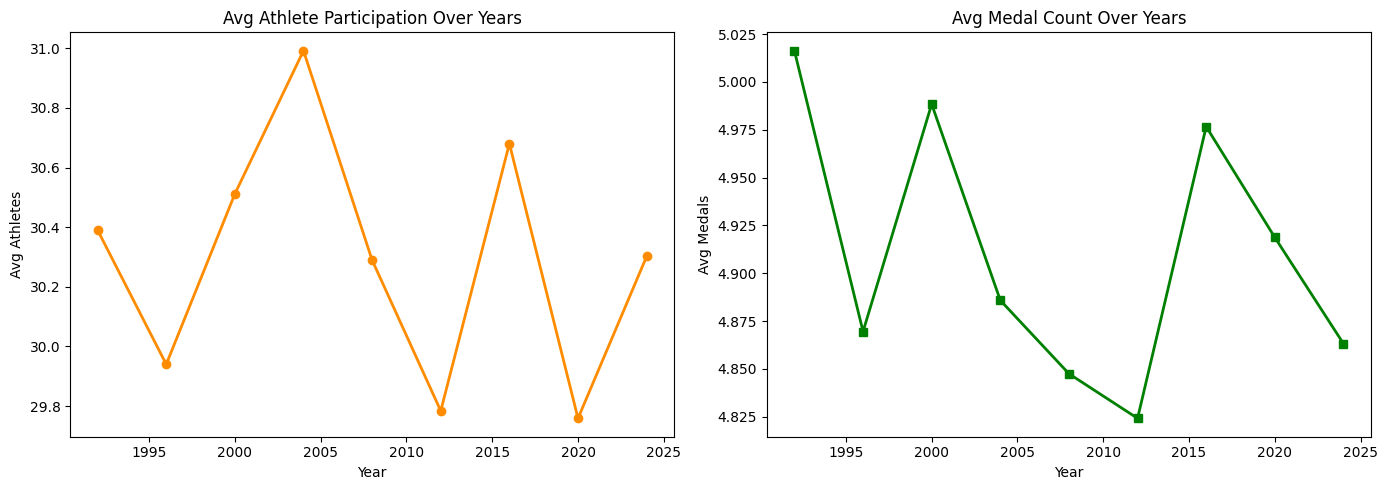

In [9]:
# CELL 8 - EDA : LINE PLOTS (Participation & Medal Trends)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yr_ath = df.groupby("Year")["Athletes"].mean()
axes[0].plot(yr_ath.index, yr_ath.values, marker="o", color="darkorange", linewidth=2)
axes[0].set_title("Avg Athlete Participation Over Years")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Avg Athletes")

yr_med = df.groupby("Year")["Total_Medals"].mean()
axes[1].plot(yr_med.index, yr_med.values, marker="s", color="green", linewidth=2)
axes[1].set_title("Avg Medal Count Over Years")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Avg Medals")

plt.tight_layout()
plt.show()

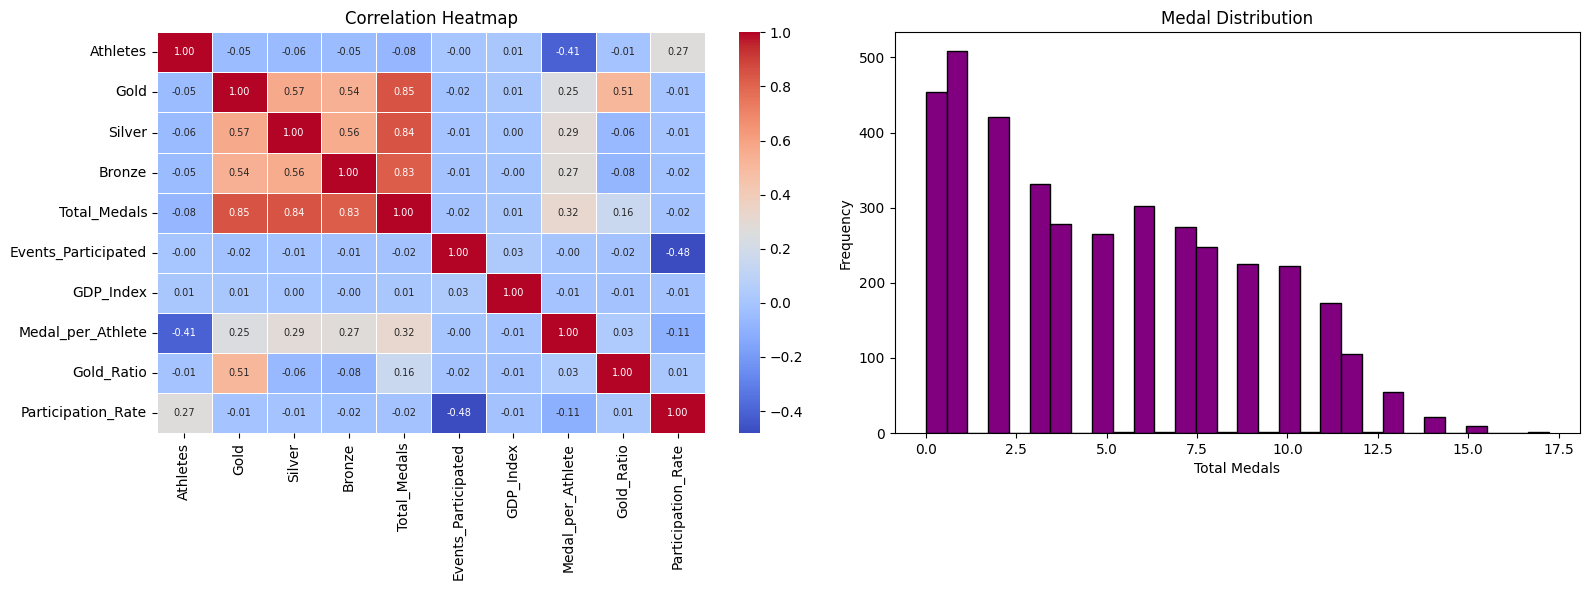

In [10]:
# CELL 9 - EDA : HEATMAP & HISTOGRAM
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_cols = ["Athletes","Gold","Silver","Bronze","Total_Medals",
             "Events_Participated","GDP_Index","Medal_per_Athlete",
             "Gold_Ratio","Participation_Rate"]
sns.heatmap(df[corr_cols].corr(), ax=axes[0], annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.4, annot_kws={"size": 7})
axes[0].set_title("Correlation Heatmap")

axes[1].hist(df["Total_Medals"], bins=30, color="purple", edgecolor="black")
axes[1].set_title("Medal Distribution")
axes[1].set_xlabel("Total Medals")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

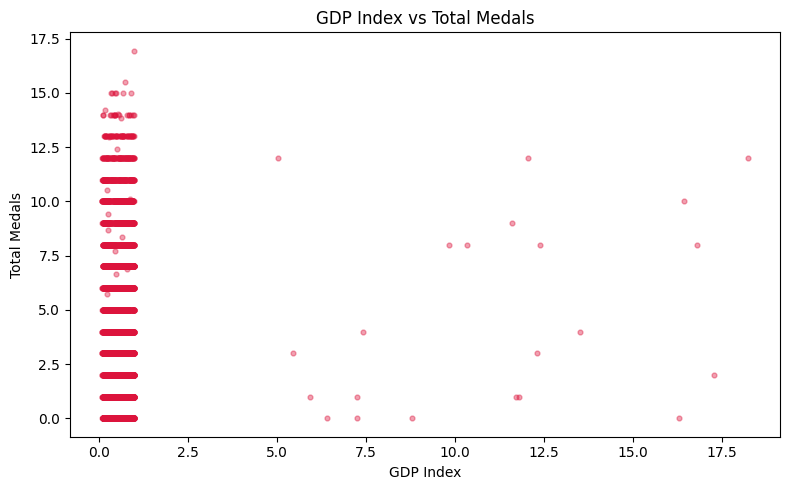

In [11]:
# CELL 10 - EDA : SCATTER (GDP vs Medals)
plt.figure(figsize=(8, 5))
plt.scatter(df["GDP_Index"], df["Total_Medals"], alpha=0.4, color="crimson", s=12)
plt.title("GDP Index vs Total Medals")
plt.xlabel("GDP Index")
plt.ylabel("Total Medals")
plt.tight_layout()
plt.show()

Correlation with Total Medals:
Gold                   0.8458
Silver                 0.8442
Bronze                 0.8259
Medal_per_Athlete      0.3192
Gold_Ratio             0.1576
GDP_Index              0.0123
Participation_Rate    -0.0173
Events_Participated   -0.0173
Athletes              -0.0754
Name: Total_Medals, dtype: float64


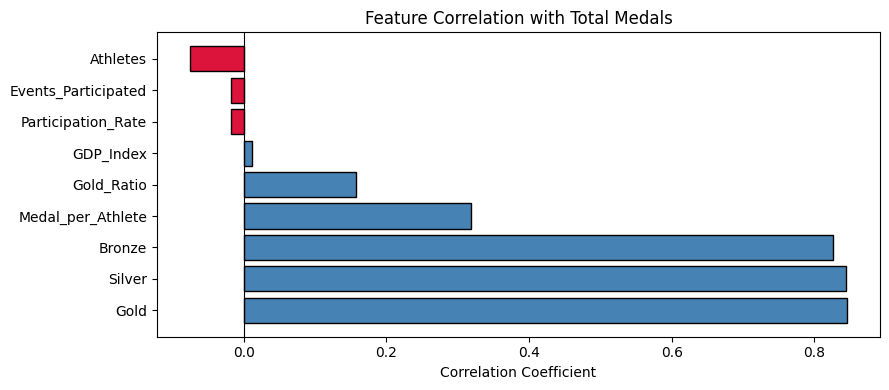

In [12]:
# CELL 11 - CORRELATION ANALYSIS
corr_with_medals = df[corr_cols].corr()["Total_Medals"].drop("Total_Medals").sort_values(ascending=False)
print("Correlation with Total Medals:")
print(corr_with_medals.round(4))

plt.figure(figsize=(9, 4))
colors = ["steelblue" if v > 0 else "crimson" for v in corr_with_medals]
plt.barh(corr_with_medals.index, corr_with_medals.values, color=colors, edgecolor="black")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Total Medals")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

PCA: 17 features → 12 components
Variance retained: 95.5%


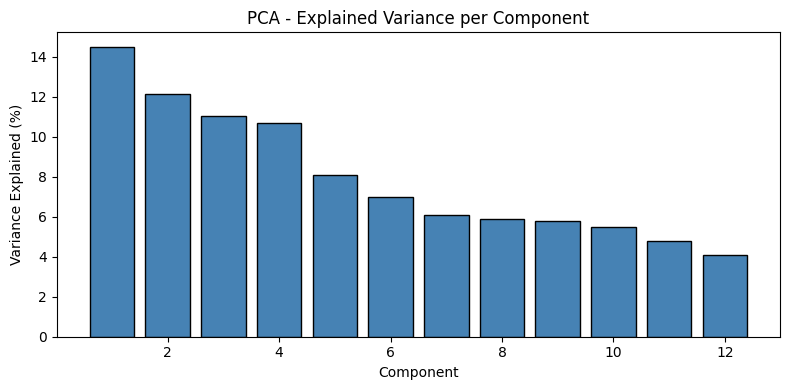

In [13]:
# CELL 12 - FEATURE SELECTION : PCA
pca   = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA: {X_scaled.shape[1]} features → {X_pca.shape[1]} components")
print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_*100, color="steelblue", edgecolor="black")
plt.title("PCA - Explained Variance per Component")
plt.xlabel("Component")
plt.ylabel("Variance Explained (%)")
plt.tight_layout()
plt.show()

In [14]:
# CELL 13 - FEATURE SELECTION : FORWARD & BACKWARD
y_reg =y_reg.fillna(y_reg.median())
rf_est = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

fwd = SequentialFeatureSelector(rf_est, n_features_to_select=5, direction="forward", cv=3, n_jobs=-1)
fwd.fit(X_scaled, y_reg)
fwd_feats = [features[i] for i, v in enumerate(fwd.get_support()) if v]
print("Forward Selection :", fwd_feats)

bwd = SequentialFeatureSelector(rf_est, n_features_to_select=5, direction="backward", cv=3, n_jobs=-1)
bwd.fit(X_scaled, y_reg)
bwd_feats = [features[i] for i, v in enumerate(bwd.get_support()) if v]
print("Backward Selection :", bwd_feats)

Forward Selection : ['Athletes', 'Prev_Medals', 'Medal_per_Athlete', 'Gold_Ratio', 'Athletes_Squared']
Backward Selection : ['Athletes', 'Medal_per_Athlete', 'Medals_per_Million', 'Host_x_Athletes', 'Log_Population']


In [15]:
# CELL 14 - CLASSIFICATION : Train/Test Split & Labels
q33 = df["Total_Medals"].quantile(0.33)
q66 = df["Total_Medals"].quantile(0.66)

y_cls = df["Total_Medals"].apply(lambda v: "High" if v >= q66 else ("Medium" if v >= q33 else "Low"))

print("Class distribution:")
print(y_cls.value_counts())

X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
print(f"Train: {len(X_tr)}  Test: {len(X_te)}")

Class distribution:
Total_Medals
Low       2061
Medium    1601
High      1338
Name: count, dtype: int64
Train: 4000  Test: 1000


In [16]:
# CELL 15 - CLASSIFICATION : Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_tr, y_tr)
lr_pred = lr.predict(X_te)
lr_f1   = f1_score(y_te, lr_pred, average="weighted")

print(f"Logistic Regression - F1 Score: {lr_f1:.4f}")
print(classification_report(y_te, lr_pred, zero_division=0))

Logistic Regression - F1 Score: 0.6246
              precision    recall  f1-score   support

        High       0.76      0.79      0.78       268
         Low       0.64      0.70      0.67       412
      Medium       0.49      0.41      0.45       320

    accuracy                           0.63      1000
   macro avg       0.63      0.63      0.63      1000
weighted avg       0.62      0.63      0.62      1000



In [17]:
# CELL 16 - CLASSIFICATION : Random Forest
rf_cls = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cls.fit(X_tr, y_tr)
rf_pred = rf_cls.predict(X_te)
rf_f1   = f1_score(y_te, rf_pred, average="weighted")

print(f"Random Forest - F1 Score: {rf_f1:.4f}")
print(classification_report(y_te, rf_pred, zero_division=0))

Random Forest - F1 Score: 0.9669
              precision    recall  f1-score   support

        High       0.97      0.93      0.95       268
         Low       0.99      0.99      0.99       412
      Medium       0.94      0.96      0.95       320

    accuracy                           0.97      1000
   macro avg       0.97      0.96      0.96      1000
weighted avg       0.97      0.97      0.97      1000



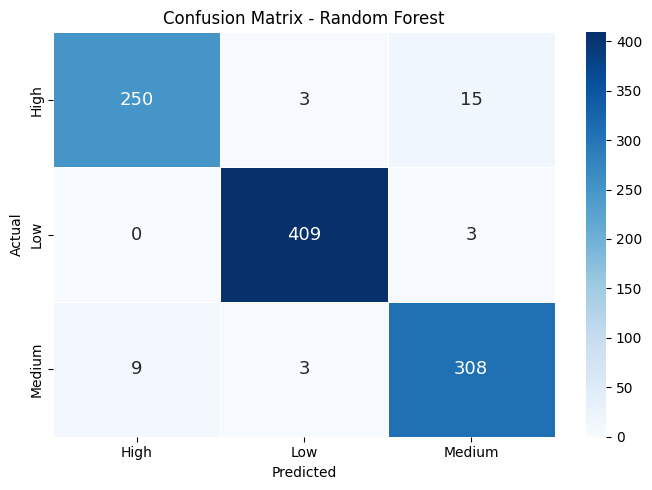

In [18]:
# CELL 17 - CONFUSION MATRIX
labels = ["High", "Low", "Medium"]
cm = confusion_matrix(y_te, rf_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, annot_kws={"size": 13})
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [19]:
# CELL 18 - REGRESSION : Train/Test Split
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_scaled, y_reg, test_size=0.1, random_state=42
)
print(f"Train: {len(X_tr_r)}  Test: {len(X_te_r)}")

Train: 4500  Test: 500


In [20]:
# CELL 19 - REGRESSION : Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_tr_r, y_tr_r)
lr_pred_r = lr_reg.predict(X_te_r)

rmse = np.sqrt(mean_squared_error(y_te_r, lr_pred_r))
r2   = r2_score(y_te_r, lr_pred_r)
print(f"Linear Regression - RMSE: {rmse:.4f}  R2: {r2:.4f}")

Linear Regression - RMSE: 2.1337  R2: 0.6128


In [21]:
# CELL 20 - REGRESSION : Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_tr_r, y_tr_r)
rf_pred_r = rf_reg.predict(X_te_r)

rmse_rf = np.sqrt(mean_squared_error(y_te_r, rf_pred_r))
r2_rf   = r2_score(y_te_r, rf_pred_r)
print(f"Random Forest Reg  - RMSE: {rmse_rf:.4f}  R2: {r2_rf:.4f}")

Random Forest Reg  - RMSE: 0.6724  R2: 0.9615


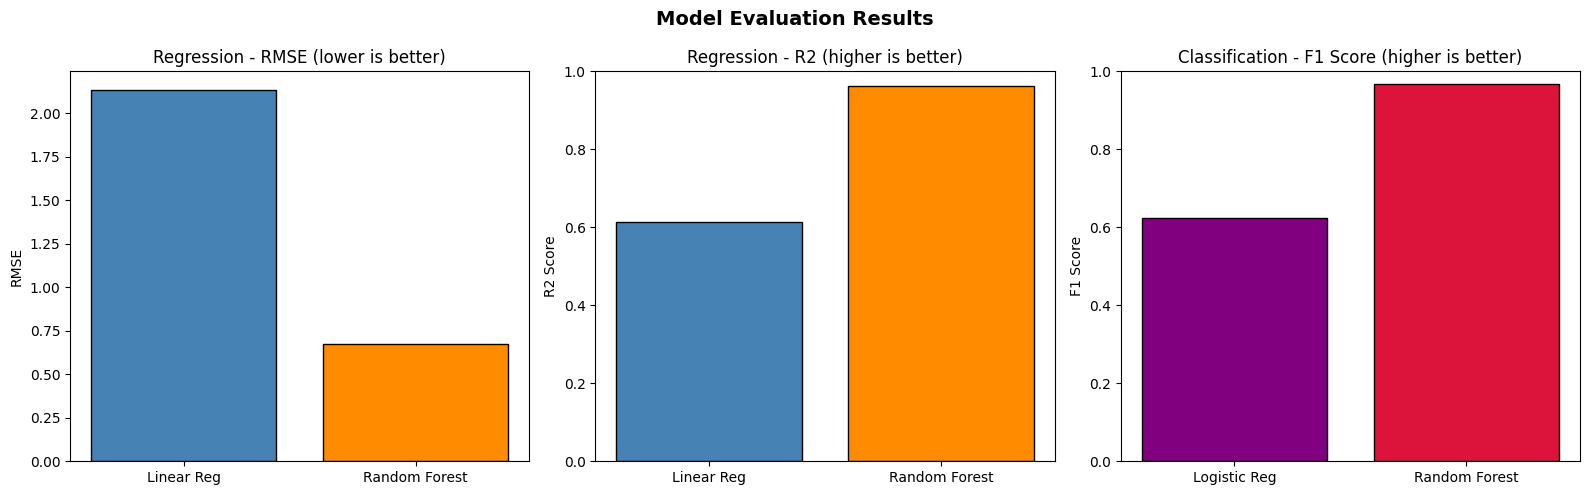

In [22]:
# CELL 21 - MODEL COMPARISON PLOT
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Evaluation Results", fontsize=14, fontweight="bold")

models_r = ["Linear Reg", "Random Forest"]
axes[0].bar(models_r, [rmse, rmse_rf], color=["steelblue","darkorange"], edgecolor="black")
axes[0].set_title("Regression - RMSE (lower is better)")
axes[0].set_ylabel("RMSE")

axes[1].bar(models_r, [r2, r2_rf], color=["steelblue","darkorange"], edgecolor="black")
axes[1].set_title("Regression - R2 (higher is better)")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("R2 Score")

models_c = ["Logistic Reg", "Random Forest"]
axes[2].bar(models_c, [lr_f1, rf_f1], color=["purple","crimson"], edgecolor="black")
axes[2].set_title("Classification - F1 Score (higher is better)")
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("F1 Score")

plt.tight_layout()
plt.show()

In [23]:
# CELL 22 - FINAL SUMMARY
print("=" * 55)
print("  FINAL SUMMARY - Question 26")
print("=" * 55)
print(f"Dataset rows            : {df.shape[0]}")
print(f"Features used           : {len(features)}")
print(f"PCA components          : {X_pca.shape[1]}")
print(f"Forward Selection       : {fwd_feats}")
print(f"Backward Selection      : {bwd_feats}")
print(f"Regression:")
print(f"Linear Regression     : RMSE={rmse:.4f}   R2={r2:.4f}")
print(f"Random Forest         : RMSE={rmse_rf:.4f}   R2={r2_rf:.4f}")
print(f"Classification F1:")
print(f"Logistic Regression   : {lr_f1:.4f}")
print(f"Random Forest         : {rf_f1:.4f}")
print("Pipeline completed successfully!")

  FINAL SUMMARY - Question 26
Dataset rows            : 5000
Features used           : 17
PCA components          : 12
Forward Selection       : ['Athletes', 'Prev_Medals', 'Medal_per_Athlete', 'Gold_Ratio', 'Athletes_Squared']
Backward Selection      : ['Athletes', 'Medal_per_Athlete', 'Medals_per_Million', 'Host_x_Athletes', 'Log_Population']
Regression:
Linear Regression     : RMSE=2.1337   R2=0.6128
Random Forest         : RMSE=0.6724   R2=0.9615
Classification F1:
Logistic Regression   : 0.6246
Random Forest         : 0.9669
Pipeline completed successfully!


In [31]:
from sklearn.model_selection import train_test_split
X_train_c, X_test_c, y_train_c, y_test_c =train_test_split(X_scaled, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

from sklearn.ensemble import RandomForestClassifier
best_clf= RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
best_clf.fit(X_train_c, y_train_c)

proba = best_clf.predict_proba(X_test_c)
high_idx = list(best_clf.classes_).index("High")

final_predictions_df = pd.DataFrame({
    'Country': df.iloc[y_test_c.index]['Country'].values,
    'Probability': proba[:, high_idx]})

top = final_predictions_df.sort_values(by='Probability', ascending=False).head(10)
print(top.to_string(index=False))

top_row = final_predictions_df.loc[final_predictions_df['Probability'].idxmax()]
print(f"\nWinner: {top_row['Country']} | Probability: {top_row['Probability']:.4f}")

    Country  Probability
    Austria          1.0
    Estonia          1.0
New Zealand          1.0
     Mexico          1.0
     Rwanda          1.0
    Lebanon          1.0
     Panama          1.0
  Indonesia          1.0
        Uae          1.0
     Rwanda          1.0

Winner: Lebanon | Probability: 1.0000
